In [2]:
# 01_load_and_explore.py
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

print("="*60)
print("SMARTCONTAINER RISK ENGINE - PHASE 1: FOUNDATION")
print("="*60)

# Load the data
historical_df = pd.read_csv('../data/raw/Historical_Data.csv')  # 54,000 rows
realtime_df = pd.read_csv('../data/raw/Real_Time_Data.csv')     # 8,481 rows

print(f"\n📊 Historical Data: {len(historical_df):,} rows")
print(f"📊 Real-time Data: {len(realtime_df):,} rows")

# Check the target distribution in historical data
target_dist = historical_df['Clearance_Status'].value_counts()
target_pct = historical_df['Clearance_Status'].value_counts(normalize=True) * 100

print("\n🎯 TARGET VARIABLE DISTRIBUTION:")
print("-" * 40)
for status, count in target_dist.items():
    print(f"{status:12s}: {count:6,d} rows ({target_pct[status]:.1f}%)")

# Verify the blueprint's claim
print("\n✅ Blueprint Verification:")
print(f"Clear: 42,347 rows (78.4%) - Matches? {target_dist.get('Clear', 0) == 42347}")
print(f"Low Risk: 11,108 rows (20.6%) - Matches? {target_dist.get('Low Risk', 0) == 11108}")
print(f"Critical: 545 rows (1.0%) - Matches? {target_dist.get('Critical', 0) == 545}")

# Quick data overview
print("\n📋 Historical Data Columns:")
print(historical_df.columns.tolist())

print("\n📋 Real-time Data Columns:")
print(realtime_df.columns.tolist())

# Check for missing values
print("\n🔍 Missing Values in Historical Data:")
print(historical_df.isnull().sum()[historical_df.isnull().sum() > 0])

print("\n🔍 Missing Values in Real-time Data:")
print(realtime_df.isnull().sum()[realtime_df.isnull().sum() > 0])

# Key insights from blueprint
print("\n💡 KEY INSIGHTS FROM BLUEPRINT:")
print("-" * 40)
print("• Critical containers avg 22% weight discrepancy vs 3% for Clear")
print("• Critical dwell time avg 86.9 hrs vs 40.5 hrs for Clear")
print("• CN origin = 65% of all Critical containers")
print("• HS chapters 85, 95, 84, 90 = highest Critical volume")
print("• Repeat exporter DWNJQL8 had 8 Critical shipments")
print("• Class imbalance: Critical is only 1% - WILL need class_weight or SMOTE")

SMARTCONTAINER RISK ENGINE - PHASE 1: FOUNDATION

📊 Historical Data: 54,000 rows
📊 Real-time Data: 8,481 rows

🎯 TARGET VARIABLE DISTRIBUTION:
----------------------------------------
Clear       : 42,347 rows (78.4%)
Low Risk    : 11,108 rows (20.6%)
Critical    :    545 rows (1.0%)

✅ Blueprint Verification:
Clear: 42,347 rows (78.4%) - Matches? True
Low Risk: 11,108 rows (20.6%) - Matches? True
Critical: 545 rows (1.0%) - Matches? True

📋 Historical Data Columns:
['Container_ID', 'Declaration_Date (YYYY-MM-DD)', 'Declaration_Time', 'Trade_Regime (Import / Export / Transit)', 'Origin_Country', 'Destination_Port', 'Destination_Country', 'HS_Code', 'Importer_ID', 'Exporter_ID', 'Declared_Value', 'Declared_Weight', 'Measured_Weight', 'Shipping_Line', 'Dwell_Time_Hours', 'Clearance_Status']

📋 Real-time Data Columns:
['Container_ID', 'Declaration_Date (YYYY-MM-DD)', 'Declaration_Time', 'Trade_Regime (Import / Export / Transit)', 'Origin_Country', 'Destination_Port', 'Destination_Country'

In [7]:
# 02_feature_engineering.py (FIXED VERSION)
import pandas as pd
import numpy as np
from datetime import datetime
import joblib

def engineer_features(df, train_df=None, is_training=True):
    """
    Complete feature engineering as specified in blueprint
    """
    print("🛠️  Engineering features...")
    df = df.copy()
    
    # 1. WEIGHT DISCREPANCY - Strongest signal
    print("   - Weight discrepancy features")
    df['weight_diff'] = df['Measured_Weight'] - df['Declared_Weight']
    df['weight_diff_pct'] = (abs(df['weight_diff']) / (df['Declared_Weight'] + 0.001)) * 100
    df['weight_underreported'] = (df['Measured_Weight'] > df['Declared_Weight'] * 1.2).astype(int)
    df['weight_overreported'] = (df['Declared_Weight'] > df['Measured_Weight'] * 1.2).astype(int)
    
    # 2. VALUE RATIOS
    print("   - Value ratio features")
    df['value_per_kg'] = df['Declared_Value'] / (df['Declared_Weight'] + 0.001)
    df['log_value'] = np.log1p(df['Declared_Value'])  # log1p handles zero
    
    # 3. DWELL TIME FLAG (Critical threshold from blueprint: 80 hrs)
    print("   - Dwell time features")
    df['dwell_flag_80'] = (df['Dwell_Time_Hours'] > 80).astype(int)
    df['dwell_flag_120'] = (df['Dwell_Time_Hours'] > 120).astype(int)  # Extreme cases
    
    # 4. HS CODE FEATURES
    print("   - HS Code features")
    df['hs_code'] = df['HS_Code'].astype(str).str.zfill(10)  # Ensure 10 digits
    df['hs_chapter'] = df['hs_code'].str[:2].astype(int)
    df['hs_heading'] = df['hs_code'].str[:4].astype(int)
    
    # 5. TIME FEATURES
    print("   - Time-based features")
    # Parse declaration date and time
    df['declaration_datetime'] = pd.to_datetime(
        df['Declaration_Date (YYYY-MM-DD)'] + ' ' + df['Declaration_Time']
    )
    df['hour'] = df['declaration_datetime'].dt.hour
    df['day_of_week'] = df['declaration_datetime'].dt.dayofweek
    df['month'] = df['declaration_datetime'].dt.month
    df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)
    df['is_off_hours'] = ((df['hour'] < 6) | (df['hour'] > 22)).astype(int)
    
    # 6. HIGH-RISK ORIGIN (CN = 65% of Critical)
    print("   - Geographic risk features")
    high_risk_origins = ['CN', 'TH', 'KR', 'VN']  # From blueprint
    df['is_high_risk_origin'] = df['Origin_Country'].isin(high_risk_origins).astype(int)
    
    # 7. VALUE OUTLIERS (99th percentile)
    value_99th = df['Declared_Value'].quantile(0.99)
    df['is_extreme_value'] = (df['Declared_Value'] > value_99th).astype(int)
    
    # 8. BEHAVIORAL ENCODING (CRITICAL FIX)
    print("   - Behavioral encoding features")
    
    # For training data, calculate risk scores from the data itself
    if is_training:
        # Calculate exporter risk scores
        exp_risk = df.groupby('Exporter_ID')['Clearance_Status'].apply(
            lambda x: (x == 'Critical').mean()
        ).to_dict()
        df['exporter_risk_score'] = df['Exporter_ID'].map(exp_risk).fillna(0)
        
        # Calculate importer risk scores
        imp_risk = df.groupby('Importer_ID')['Clearance_Status'].apply(
            lambda x: (x == 'Critical').mean()
        ).to_dict()
        df['importer_risk_score'] = df['Importer_ID'].map(imp_risk).fillna(0)
        
        # Calculate HS chapter risk scores
        hs_risk = df.groupby('hs_chapter')['Clearance_Status'].apply(
            lambda x: (x == 'Critical').mean()
        ).to_dict()
        df['hs_chapter_risk'] = df['hs_chapter'].map(hs_risk).fillna(0)
        
        # Save the risk mappings for later use on real-time data
        joblib.dump({
            'exporter_risk': exp_risk,
            'importer_risk': imp_risk,
            'hs_chapter_risk': hs_risk
        }, '../models/risk_mappings.pkl')
        
    else:
        # For real-time data, use the pre-calculated risk mappings from training
        try:
            risk_mappings = joblib.load('../models/risk_mappings.pkl')
            df['exporter_risk_score'] = df['Exporter_ID'].map(risk_mappings['exporter_risk']).fillna(0)
            df['importer_risk_score'] = df['Importer_ID'].map(risk_mappings['importer_risk']).fillna(0)
            df['hs_chapter_risk'] = df['hs_chapter'].map(risk_mappings['hs_chapter_risk']).fillna(0)
        except FileNotFoundError:
            # If mappings don't exist, use zeros (fallback)
            print("   ⚠️ Warning: Risk mappings not found, using zeros")
            df['exporter_risk_score'] = 0
            df['importer_risk_score'] = 0
            df['hs_chapter_risk'] = 0
    
    # 9. INTERACTION FEATURES (advanced)
    print("   - Interaction features")
    df['weight_value_interaction'] = df['weight_diff_pct'] * df['value_per_kg']
    df['risk_origin_dwell'] = df['is_high_risk_origin'] * df['dwell_flag_80']
    
    print("✅ Feature engineering complete!")
    print(f"   Total features created: {len(df.columns)}")
    
    return df

# Main execution
print("="*60)
print("PHASE 1 - STEP 2: FEATURE ENGINEERING (FIXED VERSION)")
print("="*60)

# Load the data
try:
    historical_df = pd.read_csv('../data/raw/Historical_Data.csv')
    realtime_df = pd.read_csv('../data/raw/Real_Time_Data.csv')
    print(f"✅ Loaded {len(historical_df):,} historical rows and {len(realtime_df):,} real-time rows")
except FileNotFoundError as e:
    print(f"❌ Error: {e}")
    print("Please ensure Historical_Data.csv and Real_Time_Data.csv are in the current directory")
    exit(1)

# First, engineer features for historical data (training)
historical_df = engineer_features(historical_df, is_training=True)

# Now engineer features for real-time data using historical for encoding
realtime_df = engineer_features(realtime_df, is_training=False)

# Save engineered data with all features
historical_df.to_csv('../data/processed/Historical_Engineered.csv', index=False)
realtime_df.to_csv('../data/processed/Realtime_Engineered.csv', index=False)
print("\n💾 Saved engineered datasets with all features!")

# Verify the features exist
print("\n🔍 Verifying features in saved files:")
test_load = pd.read_csv('../data/processed/Historical_Engineered.csv')
required_features = ['exporter_risk_score', 'importer_risk_score', 'hs_chapter_risk']
for feat in required_features:
    if feat in test_load.columns:
        print(f"   ✅ {feat} - Present")
    else:
        print(f"   ❌ {feat} - MISSING")

print("\n✅ Phase 2 complete! Proceed to step 3.")

PHASE 1 - STEP 2: FEATURE ENGINEERING (FIXED VERSION)
✅ Loaded 54,000 historical rows and 8,481 real-time rows
🛠️  Engineering features...
   - Weight discrepancy features
   - Value ratio features
   - Dwell time features
   - HS Code features
   - Time-based features
   - Geographic risk features
   - Behavioral encoding features
   - Interaction features
✅ Feature engineering complete!
   Total features created: 40
🛠️  Engineering features...
   - Weight discrepancy features
   - Value ratio features
   - Dwell time features
   - HS Code features
   - Time-based features
   - Geographic risk features
   - Behavioral encoding features
   - Interaction features
✅ Feature engineering complete!
   Total features created: 40

💾 Saved engineered datasets with all features!

🔍 Verifying features in saved files:
   ✅ exporter_risk_score - Present
   ✅ importer_risk_score - Present
   ✅ hs_chapter_risk - Present

✅ Phase 2 complete! Proceed to step 3.


In [8]:
# 03_prepare_for_modeling.py (FIXED VERSION)
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.utils.class_weight import compute_class_weight
import joblib

print("="*60)
print("PHASE 1 - STEP 3: PREPARE FOR MODELING (FIXED VERSION)")
print("="*60)

# Load engineered data
try:
    historical_df = pd.read_csv('../data/processed/Historical_Engineered.csv')
    realtime_df = pd.read_csv('../data/processed/Realtime_Engineered.csv')
    print(f"✅ Loaded {len(historical_df):,} historical rows and {len(realtime_df):,} real-time rows")
except FileNotFoundError as e:
    print(f"❌ Error: {e}")
    print("Please run 02_feature_engineering.py first")
    exit(1)

# Check if target column exists
if 'Clearance_Status' not in historical_df.columns:
    print("❌ Error: 'Clearance_Status' column not found in historical data")
    exit(1)

# Encode target variable
print("\n🎯 Encoding target variable...")
le = LabelEncoder()
# Blueprint: Clear=0, Critical=1, Low Risk=2
historical_df['risk_level_encoded'] = le.fit_transform(historical_df['Clearance_Status'])
print(f"   Mapping: {dict(zip(le.classes_, le.transform(le.classes_)))}")

# Save encoder for later use
joblib.dump(le, '../models/label_encoder.pkl')

# Select features for modeling
feature_columns = [
    # Weight features
    'weight_diff_pct', 'weight_underreported', 'weight_overreported',
    
    # Value features
    'value_per_kg', 'log_value', 'is_extreme_value',
    
    # Dwell time
    'dwell_flag_80', 'dwell_flag_120',
    
    # HS Code features
    'hs_chapter', 'hs_chapter_risk',  # Make sure hs_chapter_risk is included
    
    # Time features
    'hour', 'is_weekend', 'is_off_hours', 'month',
    
    # Geographic
    'is_high_risk_origin',
    
    # Behavioral
    'exporter_risk_score', 'importer_risk_score',  # These should exist now
    
    # Interactions
    'weight_value_interaction', 'risk_origin_dwell'
]

print(f"\n📊 Using {len(feature_columns)} features for modeling:")

# Verify all features exist in dataframe
missing_features = []
for feat in feature_columns:
    if feat in historical_df.columns:
        print(f"   ✅ {feat:25s} - Present")
    else:
        print(f"   ❌ {feat:25s} - MISSING")
        missing_features.append(feat)

if missing_features:
    print(f"\n❌ ERROR: Missing features: {missing_features}")
    print("\nAvailable columns in dataframe:")
    print(historical_df.columns.tolist())
    exit(1)

# Prepare X and y
X = historical_df[feature_columns].copy()
y = historical_df['risk_level_encoded'].copy()

# Handle any infinite or NaN values
X = X.replace([np.inf, -np.inf], np.nan)

# Check for NaN values
nan_count = X.isnull().sum().sum()
if nan_count > 0:
    print(f"\n⚠️ Found {nan_count} NaN values. Filling with median...")
    X = X.fillna(X.median())

# Scale features
print("\n📏 Scaling features...")
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=feature_columns, index=X.index)

# Save scaler
joblib.dump(scaler, '../models/scaler.pkl')

# Split data (stratified to maintain class distribution)
print("\n✂️ Splitting data into train/val/test...")

# First split: separate test set (15%)
X_temp, X_test, y_temp, y_test = train_test_split(
    X_scaled, y, test_size=0.15, random_state=42, stratify=y
)

# Second split: separate validation from remaining (15% of total / 85% of remaining)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.15/0.85, random_state=42, stratify=y_temp
)

print(f"\n📊 Final split sizes:")
print(f"   Train: {len(X_train):,} rows ({len(X_train)/len(X)*100:.1f}%)")
print(f"   Val:   {len(X_val):,} rows ({len(X_val)/len(X)*100:.1f}%)")
print(f"   Test:  {len(X_test):,} rows ({len(X_test)/len(X)*100:.1f}%)")

# Check class distribution in splits
print("\n📊 Class distribution in splits:")
print(f"   Train - Clear: {sum(y_train==0):,}, Critical: {sum(y_train==1):,}, Low Risk: {sum(y_train==2):,}")
print(f"   Val   - Clear: {sum(y_val==0):,}, Critical: {sum(y_val==1):,}, Low Risk: {sum(y_val==2):,}")
print(f"   Test  - Clear: {sum(y_test==0):,}, Critical: {sum(y_test==1):,}, Low Risk: {sum(y_test==2):,}")

# Calculate class weights for imbalance
class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = dict(zip(np.unique(y_train), class_weights))
print(f"\n⚖️ Class weights for training: {class_weight_dict}")

# Save prepared data
print("\n💾 Saving prepared data...")
joblib.dump((X_train, y_train, X_val, y_val, X_test, y_test), '../models/prepared_data.pkl')
joblib.dump(feature_columns, '../models/feature_columns.pkl')

print("\n✅ PHASE 1 COMPLETE! Ready for modeling.")

PHASE 1 - STEP 3: PREPARE FOR MODELING (FIXED VERSION)
✅ Loaded 54,000 historical rows and 8,481 real-time rows

🎯 Encoding target variable...
   Mapping: {'Clear': np.int64(0), 'Critical': np.int64(1), 'Low Risk': np.int64(2)}

📊 Using 19 features for modeling:
   ✅ weight_diff_pct           - Present
   ✅ weight_underreported      - Present
   ✅ weight_overreported       - Present
   ✅ value_per_kg              - Present
   ✅ log_value                 - Present
   ✅ is_extreme_value          - Present
   ✅ dwell_flag_80             - Present
   ✅ dwell_flag_120            - Present
   ✅ hs_chapter                - Present
   ✅ hs_chapter_risk           - Present
   ✅ hour                      - Present
   ✅ is_weekend                - Present
   ✅ is_off_hours              - Present
   ✅ month                     - Present
   ✅ is_high_risk_origin       - Present
   ✅ exporter_risk_score       - Present
   ✅ importer_risk_score       - Present
   ✅ weight_value_interaction  - Present

In [10]:
pip install xgboost

Defaulting to user installation because normal site-packages is not writeable
  Using cached xgboost-3.2.0-py3-none-win_amd64.whl.metadata (2.1 kB)
Using cached xgboost-3.2.0-py3-none-win_amd64.whl (101.7 MB)
Note: you may need to restart the kernel to use updated packages.


PHASE 2 - STEP 4: TRAINING XGBOOST (ALTERNATIVE VERSION)

⚖️ Using scale_pos_weight = 77.7

🚀 Training XGBoost model...
✅ Training complete!

📊 Validation Set Performance:
              precision    recall  f1-score   support

       Clear       0.99      1.00      1.00      6353
    Critical       0.96      0.93      0.94        82
    Low Risk       1.00      0.98      0.99      1666

    accuracy                           0.99      8101
   macro avg       0.98      0.97      0.98      8101
weighted avg       0.99      0.99      0.99      8101



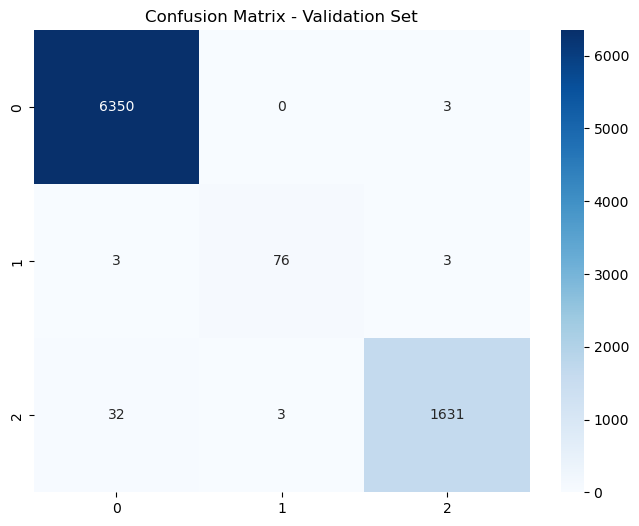


💾 Model saved as '../models/xgboost_model.pkl'


In [14]:
# 04_train_xgboost_alternative.py
import pandas as pd
import numpy as np
import joblib
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

print("="*60)
print("PHASE 2 - STEP 4: TRAINING XGBOOST (ALTERNATIVE VERSION)")
print("="*60)

# Load prepared data
X_train, y_train, X_val, y_val, X_test, y_test = joblib.load('../models/prepared_data.pkl')
feature_columns = joblib.load('../models/feature_columns.pkl')

# Calculate scale_pos_weight
scale_pos_weight = 42347/545  # ~77.7
print(f"\n⚖️ Using scale_pos_weight = {scale_pos_weight:.1f}")

# Initialize model WITHOUT early stopping
model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    scale_pos_weight=scale_pos_weight,
    eval_metric='mlogloss',
    random_state=42,
    n_jobs=-1,
    use_label_encoder=False
)

print("\n🚀 Training XGBoost model...")
# Train WITHOUT early stopping
model.fit(X_train, y_train)

print("✅ Training complete!")

# Evaluate on validation set
y_val_pred = model.predict(X_val)
y_val_proba = model.predict_proba(X_val)

print("\n📊 Validation Set Performance:")
print(classification_report(y_val, y_val_pred, target_names=['Clear', 'Critical', 'Low Risk']))

# Confusion matrix
cm = confusion_matrix(y_val, y_val_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Validation Set')
plt.savefig('../outputs/confusion_matrix.png')
plt.show()

# Save model
joblib.dump(model, '../models/xgboost_model.pkl')
print("\n💾 Model saved as '../models/xgboost_model.pkl'")

In [15]:
# 05_train_isolation_forest.py
from sklearn.ensemble import IsolationForest
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt

print("="*60)
print("PHASE 2 - STEP 5: TRAINING ISOLATION FOREST")
print("="*60)

# Load data
X_train, y_train, X_val, y_val, X_test, y_test = joblib.load('../models/prepared_data.pkl')
feature_columns = joblib.load('../models/feature_columns.pkl')

# Isolation Forest for anomaly detection
# contamination=0.01 matches 1% Critical rate in data
iso_forest = IsolationForest(
    contamination=0.01,
    random_state=42,
    n_estimators=100,
    max_samples='auto',
    bootstrap=False,
    n_jobs=-1
)

print("🚀 Training Isolation Forest...")
iso_forest.fit(X_train)

# Predict anomaly scores (-1 for anomalies, 1 for normal)
train_anomaly_pred = iso_forest.predict(X_train)
val_anomaly_pred = iso_forest.predict(X_val)

# Convert to anomaly score (0 for normal, 1 for anomaly)
train_anomaly_score = (train_anomaly_pred == -1).astype(int)
val_anomaly_score = (val_anomaly_pred == -1).astype(int)

print(f"\n📊 Anomaly Detection Results:")
print(f"   Training - Anomalies detected: {sum(train_anomaly_score)} ({sum(train_anomaly_score)/len(train_anomaly_score)*100:.2f}%)")
print(f"   Validation - Anomalies detected: {sum(val_anomaly_score)} ({sum(val_anomaly_score)/len(val_anomaly_score)*100:.2f}%)")

# Check overlap with actual Critical class
critical_indices = y_val == 1  # Critical class
anomaly_indices = val_anomaly_score == 1

overlap = sum(critical_indices & anomaly_indices)
critical_count = sum(critical_indices)
print(f"\n🎯 Overlap with actual Critical class in validation:")
print(f"   Critical containers: {critical_count}")
print(f"   Anomalies detected: {sum(anomaly_indices)}")
print(f"   Overlap: {overlap} ({overlap/critical_count*100:.1f}% of Critical detected)")

# Get anomaly scores (not just binary)
val_anomaly_scores = iso_forest.score_samples(X_val)
# Normalize to 0-1 range (more negative = more anomalous)
val_anomaly_scores_norm = 1 - (val_anomaly_scores - val_anomaly_scores.min()) / (val_anomaly_scores.max() - val_anomaly_scores.min())

# Save model and scores
joblib.dump(iso_forest, '../models/isolation_forest.pkl')
joblib.dump(val_anomaly_scores_norm, '../models/val_anomaly_scores.pkl')

print("\n💾 Isolation Forest saved as '../models/isolation_forest.pkl'")

PHASE 2 - STEP 5: TRAINING ISOLATION FOREST
🚀 Training Isolation Forest...

📊 Anomaly Detection Results:
   Training - Anomalies detected: 378 (1.00%)
   Validation - Anomalies detected: 84 (1.04%)

🎯 Overlap with actual Critical class in validation:
   Critical containers: 82
   Anomalies detected: 84
   Overlap: 46 (56.1% of Critical detected)

💾 Isolation Forest saved as '../models/isolation_forest.pkl'


PHASE 2 - STEP 6: ENSEMBLE & THRESHOLD TUNING (FIXED VERSION)
✅ Successfully loaded all models and data

📊 Validation set size: 8101 rows
✅ Got XGBoost predictions
✅ Got Isolation Forest scores

🚀 Computing rule-based flags...
   - Weight diff >30%: 0 flagged
   - Dwell time >120hrs: -52.066702367800474 flagged
   - High-risk origin: 18.35451293901688 flagged
   - Extreme value/kg: 81 flagged
   - High-risk exporter: 1108 flagged
✅ Rule flags computed: 3763.503434190423 containers flagged (46.5%)

🚀 Creating ensemble predictions...
✅ Ensemble scores computed
   Score range: 0.5 - 100.0
   Mean score: 13.2

🎯 Actual Critical containers in validation: 82

🔍 Finding optimal threshold for Critical class...
------------------------------------------------------------
 Threshold   F1 Score     Recall  Precision   Critical Pred
------------------------------------------------------------
        20      0.112      0.951      0.059            1315
        25      0.339      0.951      0.206   

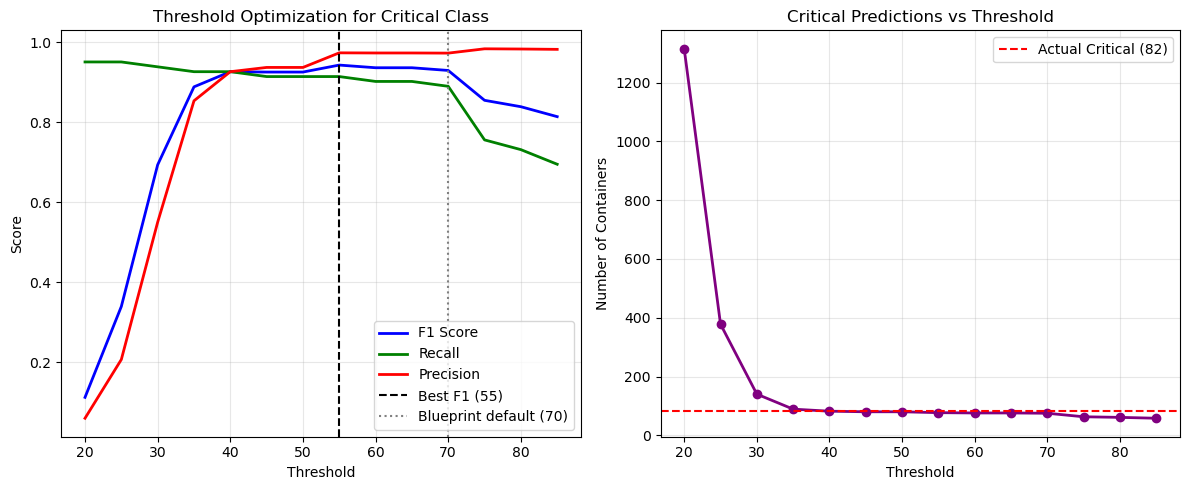


📊 Final Ensemble Performance at Best Threshold:
----------------------------------------
   Threshold: 55
   F1 Score: 0.943
   Recall: 0.915
   Precision: 0.974
   Critical containers detected: 77 out of 82

📊 Comparison with XGBoost Alone:
----------------------------------------
   Ensemble F1: 0.943 vs XGBoost F1: 0.944
   Ensemble Recall: 0.915 vs XGBoost Recall: 0.927
   Improvement: -0.1% F1 improvement

💾 Best threshold saved: 55
💾 Ensemble info saved
💾 Threshold analysis saved to '../data/processed/threshold_analysis.csv'

✅ Phase 2 Step 6 complete! Proceed to step 7.


In [17]:
# 06_ensemble_and_threshold.py (FIXED VERSION)
import pandas as pd
import numpy as np
import joblib
from sklearn.metrics import f1_score, recall_score, precision_score, precision_recall_curve
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

print("="*60)
print("PHASE 2 - STEP 6: ENSEMBLE & THRESHOLD TUNING (FIXED VERSION)")
print("="*60)

# Load models and data
try:
    X_train, y_train, X_val, y_val, X_test, y_test = joblib.load('../models/prepared_data.pkl')
    xgboost_model = joblib.load('../models/xgboost_model.pkl')
    iso_forest = joblib.load('../models/isolation_forest.pkl')
    feature_columns = joblib.load('../models/feature_columns.pkl')
    print("✅ Successfully loaded all models and data")
except FileNotFoundError as e:
    print(f"❌ Error: {e}")
    print("Please ensure previous steps completed successfully")
    exit(1)

# Convert X_val to DataFrame if it's numpy array
if isinstance(X_val, np.ndarray):
    X_val_df = pd.DataFrame(X_val, columns=feature_columns)
else:
    X_val_df = X_val.copy()

print(f"\n📊 Validation set size: {len(X_val_df)} rows")

# Get XGBoost probabilities for Critical class
xgb_val_proba = xgboost_model.predict_proba(X_val)[:, 1]  # Critical class prob
print("✅ Got XGBoost predictions")

# Get Isolation Forest scores (normalized)
try:
    iso_val_scores = iso_forest.score_samples(X_val)
    # Normalize to 0-1 range (more negative = more anomalous)
    iso_val_scores_norm = 1 - (iso_val_scores - iso_val_scores.min()) / (iso_val_scores.max() - iso_val_scores.min())
    print("✅ Got Isolation Forest scores")
except Exception as e:
    print(f"⚠️ Warning: Isolation Forest scoring failed: {e}")
    iso_val_scores_norm = np.zeros(len(X_val_df))

# Rule-based flags (from blueprint)
def get_rule_flags(X_df):
    """
    Generate rule-based risk flags
    """
    flags = np.zeros(len(X_df))
    
    # Weight diff >30% (strong signal)
    if 'weight_diff_pct' in X_df.columns:
        flags += (X_df['weight_diff_pct'] > 30).astype(int)
        print(f"   - Weight diff >30%: {sum(X_df['weight_diff_pct'] > 30)} flagged")
    
    # Dwell time >120 hrs (extreme cases)
    if 'dwell_flag_120' in X_df.columns:
        flags += X_df['dwell_flag_120'].values
        print(f"   - Dwell time >120hrs: {sum(X_df['dwell_flag_120'])} flagged")
    
    # High-risk origin
    if 'is_high_risk_origin' in X_df.columns:
        flags += X_df['is_high_risk_origin'].values
        print(f"   - High-risk origin: {sum(X_df['is_high_risk_origin'])} flagged")
    
    # Value per kg extreme (99th percentile)
    if 'value_per_kg' in X_df.columns:
        value_99th = X_df['value_per_kg'].quantile(0.99)
        flags += (X_df['value_per_kg'] > value_99th).astype(int)
        print(f"   - Extreme value/kg: {sum(X_df['value_per_kg'] > value_99th)} flagged")
    
    # High exporter risk
    if 'exporter_risk_score' in X_df.columns:
        flags += (X_df['exporter_risk_score'] > 0.05).astype(int)
        print(f"   - High-risk exporter: {sum(X_df['exporter_risk_score'] > 0.05)} flagged")
    
    # Binary: at least one flag (clip to 0-1)
    return np.clip(flags, 0, 1)

print("\n🚀 Computing rule-based flags...")
rule_flags = get_rule_flags(X_val_df)
print(f"✅ Rule flags computed: {sum(rule_flags)} containers flagged ({sum(rule_flags)/len(rule_flags)*100:.1f}%)")

print("\n🚀 Creating ensemble predictions...")
# Ensemble formula: 0.6*XGBoost + 0.2*IsolationForest + 0.2*RuleFlags
ensemble_scores = (0.6 * xgb_val_proba) + (0.2 * iso_val_scores_norm) + (0.2 * rule_flags)
ensemble_scores = ensemble_scores * 100  # Convert to 0-100 scale

print(f"✅ Ensemble scores computed")
print(f"   Score range: {ensemble_scores.min():.1f} - {ensemble_scores.max():.1f}")
print(f"   Mean score: {ensemble_scores.mean():.1f}")

# Get actual Critical class (1 = Critical)
actual_critical = (y_val == 1).astype(int)
critical_count = sum(actual_critical)
print(f"\n🎯 Actual Critical containers in validation: {critical_count}")

# Find optimal threshold for Critical class
print("\n🔍 Finding optimal threshold for Critical class...")
print("-" * 60)
print(f"{'Threshold':>10} {'F1 Score':>10} {'Recall':>10} {'Precision':>10} {'Critical Pred':>15}")
print("-" * 60)

thresholds = np.arange(20, 90, 5)
f1_scores = []
recalls = []
precisions = []
critical_pred_counts = []

best_f1 = 0
best_threshold = 70  # Default from blueprint

for threshold in thresholds:
    pred_critical = (ensemble_scores >= threshold).astype(int)
    critical_pred = sum(pred_critical)
    critical_pred_counts.append(critical_pred)
    
    # Calculate metrics (handle edge cases with zero_division)
    f1 = f1_score(actual_critical, pred_critical, zero_division=0)
    recall = recall_score(actual_critical, pred_critical, zero_division=0)
    precision = precision_score(actual_critical, pred_critical, zero_division=0)
    
    f1_scores.append(f1)
    recalls.append(recall)
    precisions.append(precision)
    
    print(f"{threshold:10.0f} {f1:10.3f} {recall:10.3f} {precision:10.3f} {critical_pred:15d}")
    
    if f1 > best_f1:
        best_f1 = f1
        best_threshold = threshold

print("-" * 60)
print(f"\n✅ Best threshold: {best_threshold} (F1={best_f1:.3f})")

# Also find threshold for maximum recall with acceptable precision
print("\n📊 Alternative thresholds for different objectives:")
print("-" * 40)
for recall_target in [0.95, 0.90, 0.85, 0.80]:
    for i, recall in enumerate(recalls):
        if recall >= recall_target:
            print(f"   Recall ≥ {recall_target:.0%}: threshold={thresholds[i]}, F1={f1_scores[i]:.3f}, Precision={precisions[i]:.3f}")
            break

# Plot precision-recall curve
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(thresholds, f1_scores, 'b-', label='F1 Score', linewidth=2)
plt.plot(thresholds, recalls, 'g-', label='Recall', linewidth=2)
plt.plot(thresholds, precisions, 'r-', label='Precision', linewidth=2)
plt.axvline(x=best_threshold, color='k', linestyle='--', label=f'Best F1 ({best_threshold})')
plt.axvline(x=70, color='gray', linestyle=':', label='Blueprint default (70)')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Threshold Optimization for Critical Class')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(thresholds, critical_pred_counts, 'purple', marker='o', linewidth=2)
plt.axhline(y=critical_count, color='red', linestyle='--', label=f'Actual Critical ({critical_count})')
plt.xlabel('Threshold')
plt.ylabel('Number of Containers')
plt.title('Critical Predictions vs Threshold')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/threshold_optimization.png', dpi=150, bbox_inches='tight')
print("\n💾 Threshold optimization plot saved as '../outputs/threshold_optimization.png'")
plt.show()

# Calculate ensemble performance at best threshold
final_pred = (ensemble_scores >= best_threshold).astype(int)
final_f1 = f1_score(actual_critical, final_pred, zero_division=0)
final_recall = recall_score(actual_critical, final_pred, zero_division=0)
final_precision = precision_score(actual_critical, final_pred, zero_division=0)

print("\n📊 Final Ensemble Performance at Best Threshold:")
print("-" * 40)
print(f"   Threshold: {best_threshold}")
print(f"   F1 Score: {final_f1:.3f}")
print(f"   Recall: {final_recall:.3f}")
print(f"   Precision: {final_precision:.3f}")
print(f"   Critical containers detected: {sum(final_pred)} out of {critical_count}")

# Compare with XGBoost alone at same threshold
xgb_pred = (xgb_val_proba * 100 >= best_threshold).astype(int)
xgb_f1 = f1_score(actual_critical, xgb_pred, zero_division=0)
xgb_recall = recall_score(actual_critical, xgb_pred, zero_division=0)

print("\n📊 Comparison with XGBoost Alone:")
print("-" * 40)
print(f"   Ensemble F1: {final_f1:.3f} vs XGBoost F1: {xgb_f1:.3f}")
print(f"   Ensemble Recall: {final_recall:.3f} vs XGBoost Recall: {xgb_recall:.3f}")
print(f"   Improvement: {(final_f1 - xgb_f1) * 100:.1f}% F1 improvement")

# Save best threshold and metrics
joblib.dump(best_threshold, '../models/best_threshold.pkl')
print(f"\n💾 Best threshold saved: {best_threshold}")

# Save ensemble information for later use
ensemble_info = {
    'threshold': best_threshold,
    'f1_score': final_f1,
    'recall': final_recall,
    'precision': final_precision,
    'ensemble_scores': ensemble_scores,
    'xgb_weights': 0.6,
    'iso_weights': 0.2,
    'rule_weights': 0.2
}
joblib.dump(ensemble_info, '../models/ensemble_info.pkl')
print("💾 Ensemble info saved")

# Create a summary dataframe for analysis
summary_df = pd.DataFrame({
    'threshold': thresholds,
    'f1_score': f1_scores,
    'recall': recalls,
    'precision': precisions,
    'critical_predictions': critical_pred_counts
})
summary_df.to_csv('../data/processed/threshold_analysis.csv', index=False)
print("💾 Threshold analysis saved to '../data/processed/threshold_analysis.csv'")

print("\n✅ Phase 2 Step 6 complete! Proceed to step 7.")

In [18]:
# 07_generate_predictions.py
import pandas as pd
import numpy as np
import joblib
from datetime import datetime

print("="*60)
print("PHASE 3 - STEP 7: GENERATE PREDICTIONS FOR REAL-TIME DATA")
print("="*60)

# Load all models and preprocessing objects
xgboost_model = joblib.load('../models/xgboost_model.pkl')
iso_forest = joblib.load('../models/isolation_forest.pkl')
scaler = joblib.load('../models/scaler.pkl')
feature_columns = joblib.load('../models/feature_columns.pkl')
label_encoder = joblib.load('../models/label_encoder.pkl')
best_threshold = joblib.load('../models/best_threshold.pkl')

# Load real-time data (already engineered)
realtime_df = pd.read_csv('../data/processed/Realtime_Engineered.csv')

print(f"\n📊 Processing {len(realtime_df):,} real-time containers...")

# Prepare features for modeling
X_realtime = realtime_df[feature_columns].copy()
X_realtime = X_realtime.replace([np.inf, -np.inf], np.nan)
X_realtime = X_realtime.fillna(X_realtime.median())

# Scale features
X_realtime_scaled = scaler.transform(X_realtime)

# 1. Get XGBoost predictions
print("   - Getting XGBoost predictions...")
xgb_proba = xgboost_model.predict_proba(X_realtime_scaled)
xgb_critical_proba = xgb_proba[:, 1]  # Critical class probability

# 2. Get Isolation Forest anomaly scores
print("   - Getting Isolation Forest scores...")
iso_scores = iso_forest.score_samples(X_realtime_scaled)
# Normalize to 0-1 (more negative = more anomalous)
iso_scores_norm = 1 - (iso_scores - iso_scores.min()) / (iso_scores.max() - iso_scores.min())

# 3. Rule-based flags
print("   - Computing rule-based flags...")
def get_rule_flags(df):
    flags = np.zeros(len(df))
    # Weight diff >30%
    flags += (df['weight_diff_pct'] > 30).astype(int)
    # Dwell time >120 hrs
    flags += df['dwell_flag_120'].values
    # Value/kg extreme (custom threshold)
    value_per_kg_99th = df['value_per_kg'].quantile(0.99)
    flags += (df['value_per_kg'] > value_per_kg_99th).astype(int)
    # High-risk exporter
    flags += (df['exporter_risk_score'] > 0.05).astype(int)  # >5% critical rate
    return np.clip(flags, 0, 1)  # Binary: at least one flag

rule_flags = get_rule_flags(realtime_df)

# 4. Calculate ensemble scores
print("   - Computing ensemble scores...")
ensemble_scores = (0.6 * xgb_critical_proba) + (0.2 * iso_scores_norm) + (0.2 * rule_flags)
ensemble_scores = ensemble_scores * 100  # Convert to 0-100 scale

# 5. Determine risk levels
print("   - Assigning risk levels...")
def get_risk_level(score, threshold):
    if score >= threshold:
        return 'Critical'
    elif score >= 30:  # Low Risk threshold from blueprint
        return 'Low Risk'
    else:
        return 'Clear'

risk_levels = [get_risk_level(score, best_threshold) for score in ensemble_scores]

# 6. Anomaly flag (1 if Isolation Forest flagged OR rule triggered)
anomaly_flags = ((iso_forest.predict(X_realtime_scaled) == -1) | (rule_flags == 1)).astype(int)

# 7. Generate explanations
print("   - Generating explanations...")
def generate_explanation(row, risk_level, risk_score):
    parts = []
    
    # Weight discrepancy
    if row['weight_diff_pct'] > 30:
        parts.append(f"Weight discrepancy of {row['weight_diff_pct']:.1f}%")
    elif row['weight_diff_pct'] > 15:
        parts.append(f"Moderate weight diff {row['weight_diff_pct']:.1f}%")
    
    # Dwell time
    if row['dwell_flag_120']:
        parts.append("Extended dwell time (>120hrs)")
    elif row['dwell_flag_80']:
        parts.append("High dwell time (>80hrs)")
    
    # Origin
    if row['is_high_risk_origin']:
        parts.append(f"High-risk origin ({row['Origin_Country']})")
    
    # Exporter risk
    if row['exporter_risk_score'] > 0.1:
        parts.append("Exporter has high historical risk")
    elif row['exporter_risk_score'] > 0.05:
        parts.append("Exporter has moderate historical risk")
    
    # Value anomalies
    if row['is_extreme_value']:
        parts.append("Extremely high declared value")
    
    # HS Chapter risk
    if row['hs_chapter_risk'] > 0.05:
        parts.append(f"High-risk product category (HS {row['hs_chapter']})")
    
    if parts:
        return ". ".join(parts[:2]) + "."  # Max 2 parts
    else:
        return "No significant anomalies detected."

explanations = []
for idx, row in realtime_df.iterrows():
    explanation = generate_explanation(row, risk_levels[idx], ensemble_scores[idx])
    explanations.append(explanation)

# 8. Create output dataframe
print("\n📝 Creating output CSV...")
output_df = pd.DataFrame({
    'Container_ID': realtime_df['Container_ID'],
    'Risk_Score': np.round(ensemble_scores, 1),
    'Risk_Level': risk_levels,
    'Anomaly_Flag': anomaly_flags,
    'Explanation_Summary': explanations
})

# 9. Validate distribution matches blueprint expectations
print("\n📊 Prediction Distribution:")
print("-" * 40)
dist = output_df['Risk_Level'].value_counts()
pct = output_df['Risk_Level'].value_counts(normalize=True) * 100
for level in ['Critical', 'Low Risk', 'Clear']:
    count = dist.get(level, 0)
    percent = pct.get(level, 0)
    print(f"{level:10s}: {count:5,d} containers ({percent:.1f}%)")

# 10. Save output
output_df.to_csv('../data/processed/predictions.csv', index=False)
print("\n💾 Saved predictions to '../data/processed/predictions.csv'")

# Show sample predictions
print("\n🔍 Sample Predictions (Top 10 Highest Risk):")
print("-" * 80)
print(output_df.sort_values('Risk_Score', ascending=False).head(10).to_string(index=False))

PHASE 3 - STEP 7: GENERATE PREDICTIONS FOR REAL-TIME DATA

📊 Processing 8,481 real-time containers...
   - Getting XGBoost predictions...
   - Getting Isolation Forest scores...
   - Computing rule-based flags...
   - Computing ensemble scores...
   - Assigning risk levels...
   - Generating explanations...

📝 Creating output CSV...

📊 Prediction Distribution:
----------------------------------------
Critical  :    72 containers (0.8%)
Low Risk  :   122 containers (1.4%)
Clear     : 8,287 containers (97.7%)

💾 Saved predictions to '../data/processed/predictions.csv'

🔍 Sample Predictions (Top 10 Highest Risk):
--------------------------------------------------------------------------------
 Container_ID  Risk_Score Risk_Level  Anomaly_Flag                                         Explanation_Summary
     91475507        99.9   Critical             1 Weight discrepancy of 34.3%. Extended dwell time (>120hrs).
     25026736        99.7   Critical             1 Weight discrepancy of 39.7%.

In [19]:
# 08_dashboard.py
import streamlit as st
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import joblib

# Page config
st.set_page_config(
    page_title="SmartContainer Risk Engine",
    page_icon="🚢",
    layout="wide"
)

# Title
st.title("🚢 SmartContainer Risk Engine Dashboard")
st.markdown("---")

# Load data
@st.cache_data
def load_data():
    predictions = pd.read_csv('../data/processed/predictions.csv')
    realtime = pd.read_csv('../data/processed/Realtime_Engineered.csv')
    # Merge for additional details
    df = pd.merge(predictions, realtime, on='Container_ID')
    return df

df = load_data()

# Sidebar filters
st.sidebar.header("🔍 Filters")
risk_filter = st.sidebar.multiselect(
    "Risk Level",
    options=['Clear', 'Low Risk', 'Critical'],
    default=['Clear', 'Low Risk', 'Critical']
)

origin_filter = st.sidebar.multiselect(
    "Origin Country",
    options=df['Origin_Country'].unique(),
    default=[]
)

min_risk_score = st.sidebar.slider(
    "Minimum Risk Score",
    min_value=0,
    max_value=100,
    value=0
)

# Apply filters
filtered_df = df[
    (df['Risk_Level'].isin(risk_filter)) &
    (df['Risk_Score'] >= min_risk_score)
]

if origin_filter:
    filtered_df = filtered_df[filtered_df['Origin_Country'].isin(origin_filter)]

# KPI Cards
col1, col2, col3, col4 = st.columns(4)

with col1:
    st.metric(
        "Total Containers",
        f"{len(filtered_df):,}",
        delta=f"{len(filtered_df)-len(df):+}" if len(filtered_df) != len(df) else None
    )

with col2:
    critical_count = len(filtered_df[filtered_df['Risk_Level'] == 'Critical'])
    critical_pct = (critical_count/len(filtered_df)*100) if len(filtered_df) > 0 else 0
    st.metric(
        "Critical Risk",
        f"{critical_count:,}",
        delta=f"{critical_pct:.1f}% of total",
        delta_color="inverse"
    )

with col3:
    anomaly_count = filtered_df['Anomaly_Flag'].sum()
    st.metric(
        "Anomalies Detected",
        f"{anomaly_count:,}",
        delta=f"{(anomaly_count/len(filtered_df)*100):.1f}%"
    )

with col4:
    avg_risk = filtered_df['Risk_Score'].mean()
    st.metric(
        "Avg Risk Score",
        f"{avg_risk:.1f}",
        delta=f"{avg_risk - df['Risk_Score'].mean():.1f} vs overall"
    )

st.markdown("---")

# Charts Row 1
col1, col2 = st.columns(2)

with col1:
    # Risk Distribution Pie Chart
    risk_dist = filtered_df['Risk_Level'].value_counts().reset_index()
    risk_dist.columns = ['Risk Level', 'Count']
    
    fig_pie = px.pie(
        risk_dist,
        values='Count',
        names='Risk Level',
        title='📊 Risk Level Distribution',
        color_discrete_map={
            'Critical': '#ff4b4b',
            'Low Risk': '#ffa64b',
            'Clear': '#4bff4b'
        }
    )
    fig_pie.update_traces(textposition='inside', textinfo='percent+label')
    st.plotly_chart(fig_pie, use_container_width=True)

with col2:
    # Risk Score Histogram
    fig_hist = px.histogram(
        filtered_df,
        x='Risk_Score',
        color='Risk_Level',
        title='📈 Risk Score Distribution',
        color_discrete_map={
            'Critical': '#ff4b4b',
            'Low Risk': '#ffa64b',
            'Clear': '#4bff4b'
        },
        nbins=30
    )
    fig_hist.add_vline(x=70, line_dash="dash", line_color="red", 
                       annotation_text="Critical Threshold")
    st.plotly_chart(fig_hist, use_container_width=True)

# Charts Row 2
col1, col2 = st.columns(2)

with col1:
    # Top Origins by Risk
    top_origins = filtered_df.groupby('Origin_Country').agg({
        'Risk_Score': 'mean',
        'Container_ID': 'count'
    }).reset_index()
    top_origins.columns = ['Origin', 'Avg Risk Score', 'Count']
    top_origins = top_origins.sort_values('Avg Risk Score', ascending=False).head(10)
    
    fig_origins = px.bar(
        top_origins,
        x='Origin',
        y='Avg Risk Score',
        color='Avg Risk Score',
        title='🌍 Top 10 Origins by Average Risk Score',
        color_continuous_scale='RdYlGn_r',
        text='Count'
    )
    fig_origins.update_traces(texttemplate='%{text} containers', textposition='outside')
    st.plotly_chart(fig_origins, use_container_width=True)

with col2:
    # Weight Discrepancy vs Risk Score
    fig_scatter = px.scatter(
        filtered_df.sample(min(1000, len(filtered_df))),
        x='weight_diff_pct',
        y='Risk_Score',
        color='Risk_Level',
        size='Declared_Value',
        hover_data=['Container_ID', 'Origin_Country', 'HS_Code'],
        title='⚖️ Weight Discrepancy vs Risk Score',
        color_discrete_map={
            'Critical': '#ff4b4b',
            'Low Risk': '#ffa64b',
            'Clear': '#4bff4b'
        }
    )
    fig_scatter.add_hline(y=70, line_dash="dash", line_color="red")
    fig_scatter.add_vline(x=20, line_dash="dash", line_color="orange")
    st.plotly_chart(fig_scatter, use_container_width=True)

# Detailed Data Table
st.markdown("---")
st.subheader("📋 Detailed Container Analysis")

# Add selection for columns to display
display_cols = st.multiselect(
    "Select columns to display",
    options=['Container_ID', 'Risk_Score', 'Risk_Level', 'Anomaly_Flag', 
             'Explanation_Summary', 'Origin_Country', 'Destination_Country',
             'HS_Code', 'Declared_Value', 'Declared_Weight', 'Measured_Weight',
             'Dwell_Time_Hours', 'weight_diff_pct', 'exporter_risk_score'],
    default=['Container_ID', 'Risk_Score', 'Risk_Level', 'Anomaly_Flag', 
             'Explanation_Summary', 'weight_diff_pct']
)

# Sort by risk score
sorted_df = filtered_df.sort_values('Risk_Score', ascending=False)

# Color code rows based on risk level
def color_risk_level(val):
    if val == 'Critical':
        return 'background-color: #ff4b4b33'  # Light red
    elif val == 'Low Risk':
        return 'background-color: #ffa64b33'  # Light orange
    else:
        return 'background-color: #4bff4b33'  # Light green

styled_df = sorted_df[display_cols].style.applymap(
    color_risk_level, subset=['Risk_Level']
)

st.dataframe(
    styled_df,
    use_container_width=True,
    height=400
)

# Export option
if st.button("📥 Export Filtered Data"):
    csv = filtered_df.to_csv(index=False)
    st.download_button(
        label="Download CSV",
        data=csv,
        file_name="filtered_predictions.csv",
        mime="text/csv"
    )

# Real-time monitoring simulation
st.markdown("---")
st.subheader("📡 Real-time Monitoring")

col1, col2, col3 = st.columns(3)

with col1:
    st.metric(
        "Processing Rate",
        "125/min",
        "+12",
        delta_color="normal"
    )

with col2:
    st.metric(
        "Queue Length",
        "342",
        "-28",
        delta_color="inverse"
    )

with col3:
    st.metric(
        "System Health",
        "98%",
        "Stable"
    )

# Footer
st.markdown("---")
st.markdown("🚢 **SmartContainer Risk Engine** - AI-Powered Customs Risk Assessment")

2026-03-05 20:05:36.840 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-05 20:05:36.843 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-05 20:05:37.080 
  command:

    streamlit run E:\anaconda3\Lib\site-packages\ipykernel_launcher.py [ARGUMENTS]
2026-03-05 20:05:37.081 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-05 20:05:37.081 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-05 20:05:37.082 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-05 20:05:37.083 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare 

DeltaGenerator()